In [7]:
import rpy2.robjects as robjects
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
folder_name = '3_state_model'
n_states = 3

data_log = pd.read_csv(folder_name + "/close_data_log.csv")

# Helper function to convert R data.frame to pandas DataFrame
def r_to_df(r_df):
    return pd.DataFrame({name: np.array(r_df.rx2(name)) for name in r_df.names})

# Read the RDS files using rpy2
readRDS = robjects.r['readRDS']

hmm_stats_r = readRDS(folder_name + "/hmm_stats_df.rds")
hmm_stats_df = r_to_df(hmm_stats_r)

hmm_state_losses = np.array(readRDS(folder_name + "/hmm_state_losses.rds"))
hmm_predictions = np.array(readRDS(folder_name + "/hmm_predictions.rds"))
hmm_ground_truth = np.array(readRDS(folder_name + "/hmm_ground_truth.rds"))
hmm_valid_loss = np.array(readRDS(folder_name + "/hmm_valid_loss.rds"))
hmm_transition_matrix = pd.read_csv(folder_name + "/transition_matrix.csv")
#hmm_obspar = pd.read_csv(folder_name + "/obspar.csv")

X_train_orig = np.array(readRDS(folder_name + "/lstm_X_train.rds"))
Y_train_orig = np.array(readRDS(folder_name + "/lstm_Y_train.rds"))
X_valid_orig = np.array(readRDS(folder_name + "/lstm_X_valid.rds"))
Y_valid_orig = np.array(readRDS(folder_name + "/lstm_Y_valid.rds"))
X_test_orig = np.array(readRDS(folder_name + "/lstm_X_test.rds"))
Y_test_orig = np.array(readRDS(folder_name + "/lstm_Y_test.rds"))

last_state_test = X_test_orig[:, -1, :n_states]
last_state_valid = X_valid_orig[:, -1, :n_states]
last_state_train = X_train_orig[:, -1, :n_states]

first_state_test = X_test_orig[:, 0, :n_states]
first_state_valid = X_valid_orig[:, 0, :n_states]
first_state_train = X_train_orig[:, 0, :n_states]

n_states = Y_train_orig.shape[2]
X_train_orig.shape, Y_train_orig.shape, X_valid_orig.shape, Y_valid_orig.shape, X_test_orig.shape, Y_test_orig.shape

((672, 10, 20),
 (672, 10, 3),
 (234, 10, 20),
 (234, 10, 3),
 (309, 10, 20),
 (309, 10, 3))

In [9]:
X_train = last_state_train
Y_train = Y_train_orig[:, 0, :n_states]

X_valid = last_state_valid
Y_valid = Y_valid_orig[:, 0, :n_states]

X_test = last_state_test
Y_test = Y_test_orig[:, 0, :n_states]

In [28]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Simple feed-forward network: input(3) -> 3 dense layers(3) -> softmax output(3)
def build_model():
    model = models.Sequential([
        layers.Input(shape=(3,)),
        layers.Dense(3, activation='relu'),
        layers.Dense(3, activation='relu'),
        layers.Dense(3, activation='relu'),
        layers.Dense(3, activation='softmax'),
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.KLDivergence()],
    )
    return model


In [53]:
# Prepare data: use last timestep, first 3 features (state probs) as input
# and last timestep of Y as target
X_train = X_train_orig[:, -1, :n_states]
Y_train = Y_train_orig[:, 0, :]
X_valid = X_valid_orig[:, -1, :n_states]
Y_valid = Y_valid_orig[:, 0, :]
X_test = X_test_orig[:, -1, :n_states]
Y_test = Y_test_orig[:, 0, :]

print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"X_valid: {X_valid.shape}, Y_valid: {Y_valid.shape}")
print(f"X_test: {X_test.shape}, Y_test: {Y_test.shape}")

# tf.keras.backend.clear_session()
# model = build_model()
# Train
history = model.fit(
    X_train, Y_train,
    validation_data=(X_valid, Y_valid),
    epochs=50,
    batch_size=32,
    verbose=1,
)

print(f"Final train loss: {history.history['loss'][-1]:.4f}")
print(f"Final valid loss: {history.history['val_loss'][-1]:.4f}")

Y_hat_test = model.predict(X_test)
Y_hat_loss = tf.keras.losses.categorical_crossentropy(Y_test, Y_hat_test).numpy()
Y_hat_hmm_loss_test = hmm_state_losses[:, 0]
print(f"Test loss: {np.mean(Y_hat_loss):.4f}")

X_train: (672, 3), Y_train: (672, 3)
X_valid: (234, 3), Y_valid: (234, 3)
X_test: (309, 3), Y_test: (309, 3)
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7693 - kl_divergence: 0.2945 - loss: 0.6525 - val_accuracy: 0.8462 - val_kl_divergence: 0.1918 - val_loss: 0.5344
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7664 - kl_divergence: 0.2939 - loss: 0.6519 - val_accuracy: 0.8419 - val_kl_divergence: 0.1928 - val_loss: 0.5354
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7664 - kl_divergence: 0.2938 - loss: 0.6517 - val_accuracy: 0.8419 - val_kl_divergence: 0.1929 - val_loss: 0.5355
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7664 - kl_divergence: 0.2939 - loss: 0.6519 - val_accuracy: 0.8419 - val_kl_divergence: 0.1937 - val_loss: 0.5363
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7664 - kl_divergence: 0.2938 - loss: 0.6517 - val_accuracy: 0.8419 - val_kl_divergence: 0.1926 - val_loss: 0.5352
E

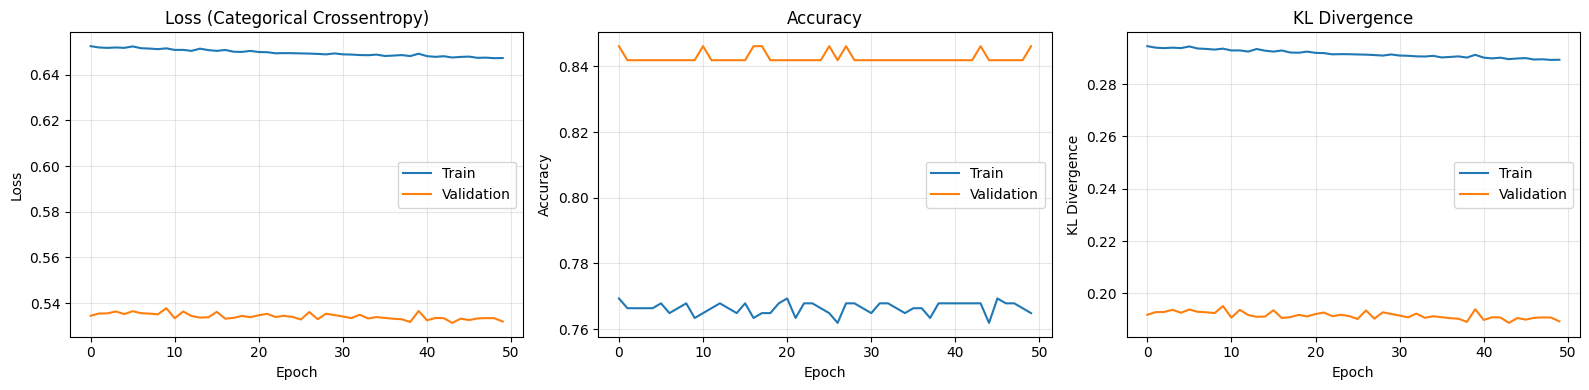

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss (Categorical Crossentropy)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# KL Divergence
axes[2].plot(history.history['kl_divergence'], label='Train')
axes[2].plot(history.history['val_kl_divergence'], label='Validation')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

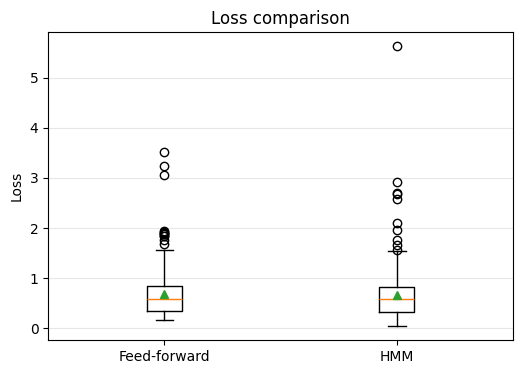

                   min        q1    median        q3       max      mean       std       iqr
Feed-forward  0.171848  0.342919  0.589956  0.844491  3.517634  0.689030  0.452799  0.501572
HMM           0.039909  0.329328  0.592399  0.816298  5.625449  0.657512  0.502083  0.486970


In [55]:
ff_losses = np.ravel(Y_hat_loss)
hmm_losses = np.ravel(Y_hat_hmm_loss_test)

plt.figure(figsize=(6, 4))
plt.boxplot([Y_hat_loss, Y_hat_hmm_loss_test], tick_labels=["Feed-forward", "HMM"], showmeans=True)
plt.ylabel("Loss")
plt.title("Loss comparison")
plt.grid(axis="y", alpha=0.3)
plt.show()

metric_names = ["min", "q1", "median", "q3", "max", "mean", "std", "iqr"]
boxplot_metrics = pd.DataFrame({
    "Feed-forward": [
        np.min(ff_losses),
        np.percentile(ff_losses, 25),
        np.median(ff_losses),
        np.percentile(ff_losses, 75),
        np.max(ff_losses),
        np.mean(ff_losses),
        np.std(ff_losses),
        np.percentile(ff_losses, 75) - np.percentile(ff_losses, 25),
    ],
    "HMM": [
        np.min(hmm_losses),
        np.percentile(hmm_losses, 25),
        np.median(hmm_losses),
        np.percentile(hmm_losses, 75),
        np.max(hmm_losses),
        np.mean(hmm_losses),
        np.std(hmm_losses),
        np.percentile(hmm_losses, 75) - np.percentile(hmm_losses, 25),
    ],
}, index=metric_names).T

print(boxplot_metrics.round(6).to_string())

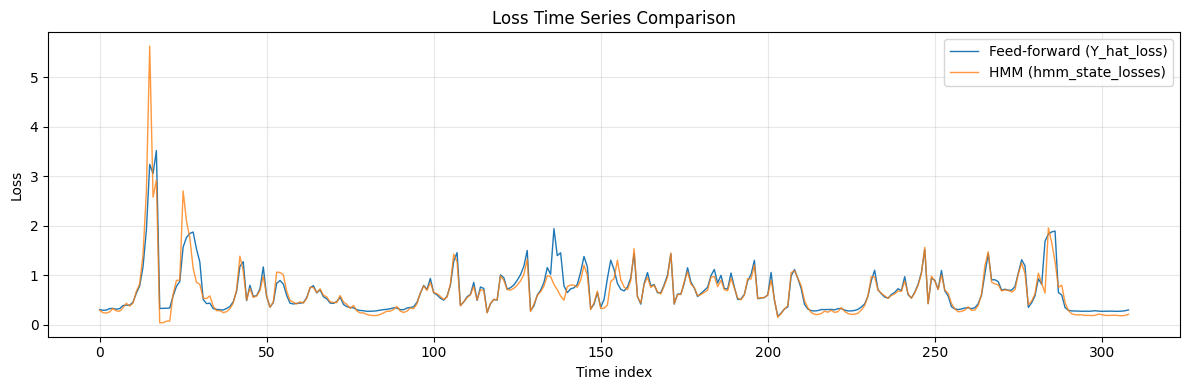

In [56]:
# Time-series plot of per-sample losses
x = np.arange(len(Y_hat_loss))

plt.figure(figsize=(12, 4))
plt.plot(x, Y_hat_loss, label="Feed-forward (Y_hat_loss)", linewidth=1)
plt.plot(x, Y_hat_hmm_loss_test, label="HMM (hmm_state_losses)", linewidth=1, alpha=0.8)
plt.xlabel("Time index")
plt.ylabel("Loss")
plt.title("Loss Time Series Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
np.concatenate([X_test, Y_hat_test], axis=1)[0:5]

array([[1.59560390e-03, 1.73392917e-01, 8.25011479e-01, 2.07676440e-02,
        2.15397537e-01, 7.63834834e-01],
       [9.11923238e-04, 1.16688556e-01, 8.82399521e-01, 2.01560464e-02,
        2.03480944e-01, 7.76363015e-01],
       [4.65897469e-04, 9.62689216e-02, 9.03265181e-01, 2.02679504e-02,
        2.01471224e-01, 7.78260887e-01],
       [3.02286536e-04, 8.20533855e-02, 9.17644328e-01, 2.10023597e-02,
        2.02751473e-01, 7.76246130e-01],
       [5.77509936e-04, 1.97950364e-01, 8.01472127e-01, 2.11379938e-02,
        2.22385153e-01, 7.56476939e-01]])